# Image analysis and pattern recognition - Final Project 

**Group ID:** 24

**Author 1 (341742):** Axel CEBILLE  
**Author 2 (345815):** Melissa RIESEN  
**Author 3 (347320):** Sophie MOSEGAARD  

**Challenge:** Classic


In [1]:
import os
import cv2
import numpy as np
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from glob import glob
import pandas as pd
from collections import defaultdict
import itertools
import csv
import itertools
import sys
sys.path.append('.')


## Pipeline overview

### Label data by hand

The fist step in processing the data was to manually label the chocolates in the refernce and training images to create annotations that could be used in subsequent processing steps.  
We used [roboflow](https://roboflow.com/), a online tool that allowed us to draw bounding boxes around the chocolates and label them. The annotation data is stored a csv file named [ _annotations.csv ](data/_annotations.csv) where each row represents a single bounding box around an object in an image. The columns include:

- **filename** - name of the image
- **width,height** - number of pixel in image
- **class** - class of the object within the box
- **xmin,ymin,xmax,ymax** - coordinates specification of the bounding box

This step was also done for all other objects and prominent background contours in the training images, as recorded in the [ _annotations_objects.csv ](data/_annotations_objects.csv) file.

In the following notebok we used *visualize_img*, a subset of the train images for visualisation purposes. These 6 images contain all possible backgrounds and a variety of different chocolates. 

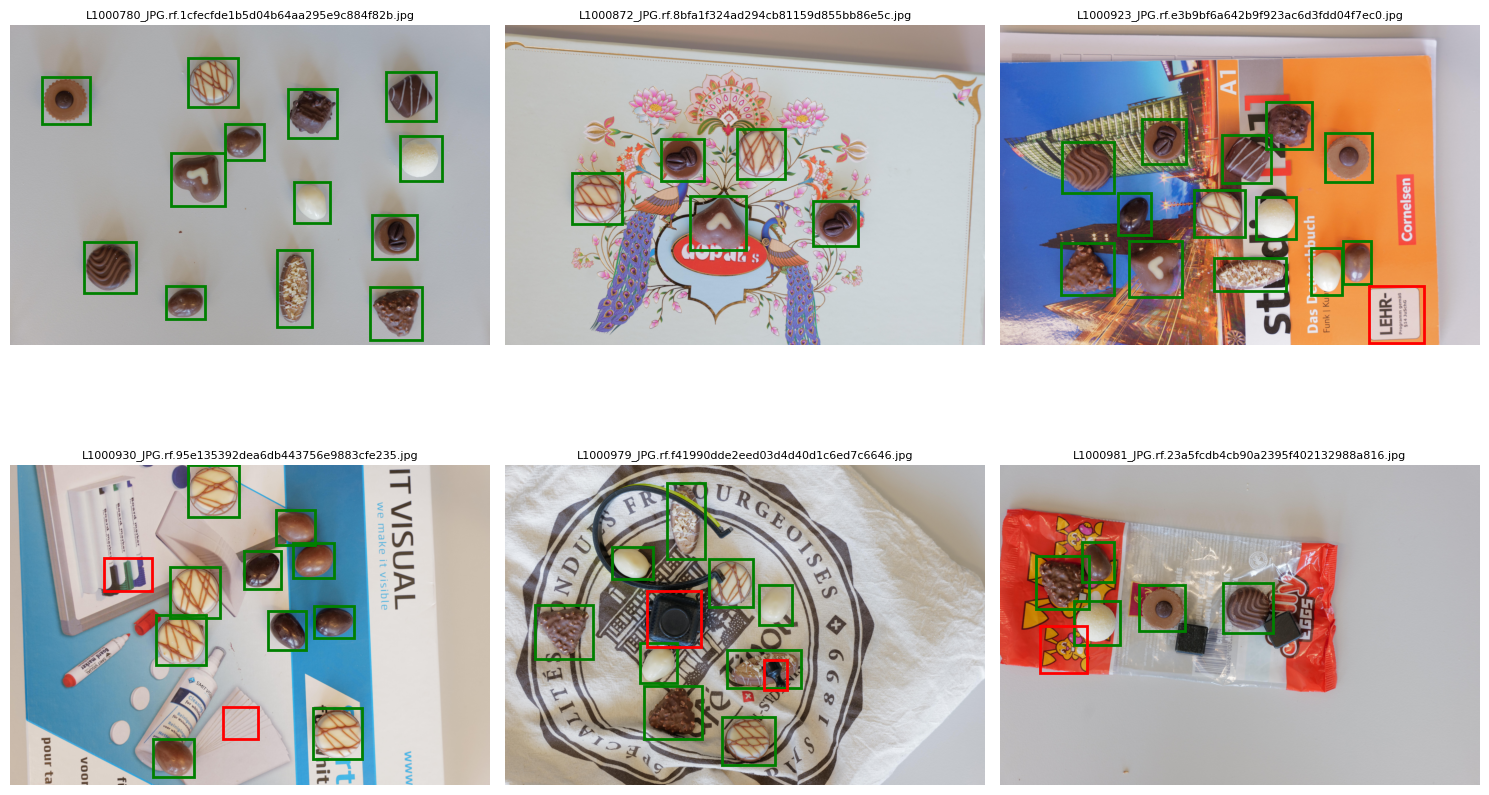

In [ ]:
from visualizations import show_bounding_boxes

visualize_img = os.path.abspath(os.path.join('images', 'report_visualization'))
annot_choc = os.path.abspath(os.path.join('data', '_annotations.csv'))
annot_obj = os.path.abspath(os.path.join('data', '_annotations_objects.csv'))

show_bounding_boxes(visualize_img, annot_choc, annot_obj)


*Figure 1:* In the images above, green bounding boxes indicate labeled chocolates, while red boxes highlight examples of other object or prominent background elements both annotated by hand.

### K-mean clustering
The images have high visual complexity due to highly different backgrounds and varying colors. We tried to reduce the complexity caused by different colors by using a K-mean clustering. For this we used the KMeans function from scikit-learn. To determine an appropriate value for k, we visually inspected the clustering results for different k values on a sample of images.

In [3]:
def kmeans_clustering(image, k=4):
    Z = image.reshape((-1, 3))
    Z = np.float32(Z)
    kmeans = KMeans(n_clusters=k, random_state=0).fit(Z)
    labels = kmeans.labels_.reshape(image.shape[:2])
    clustered_img = kmeans.cluster_centers_[labels].reshape(image.shape).astype(np.uint8)
    return clustered_img, labels

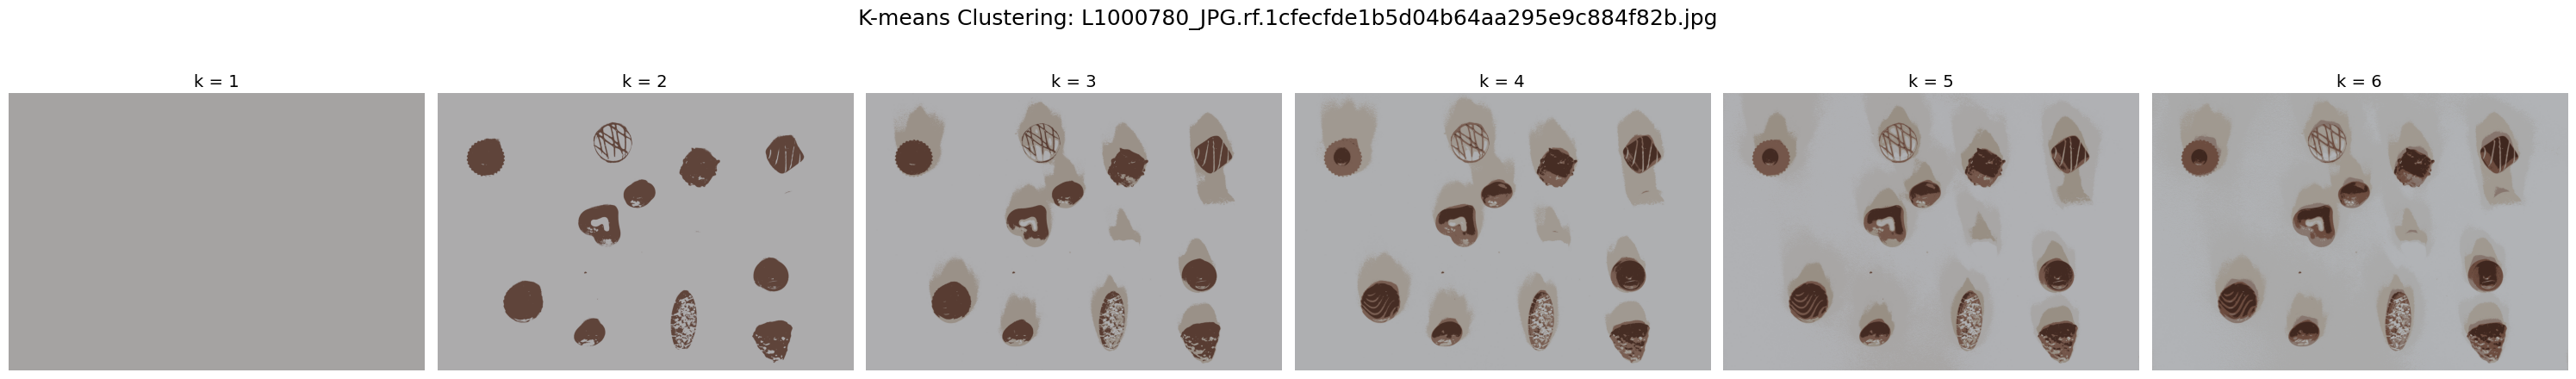

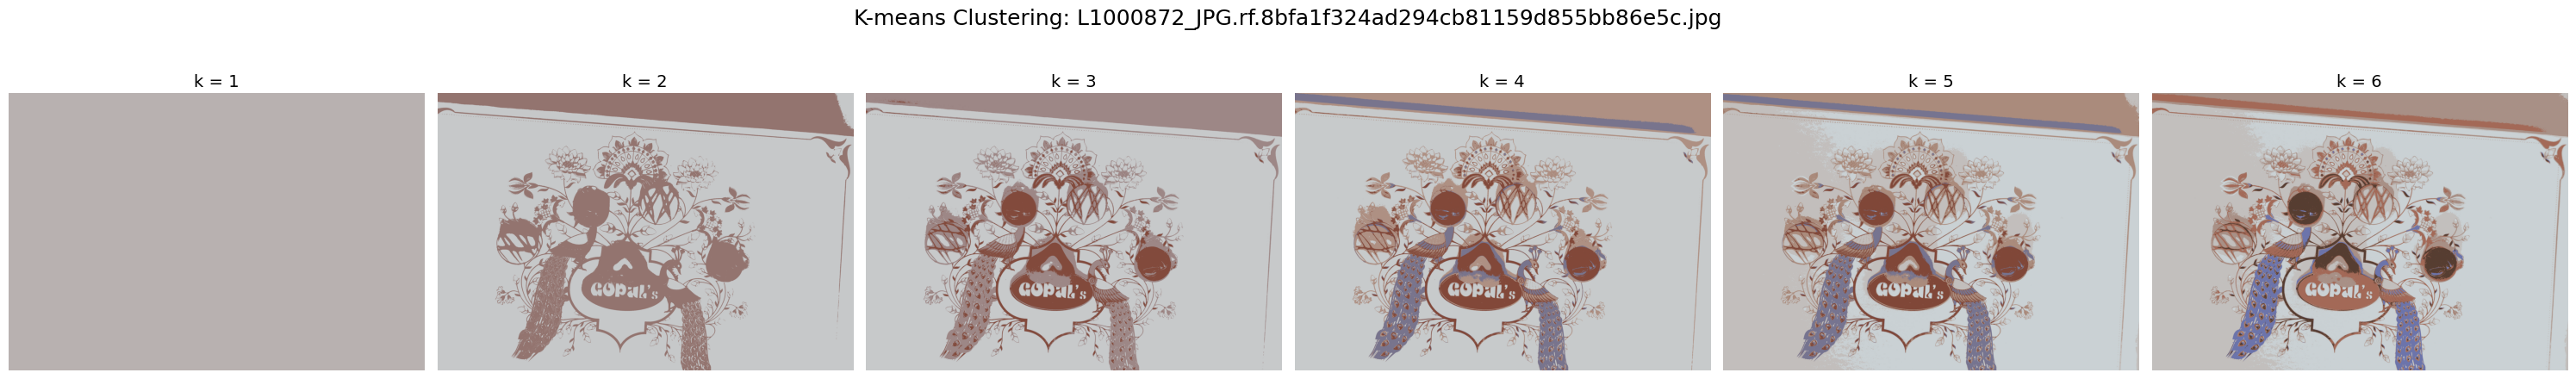

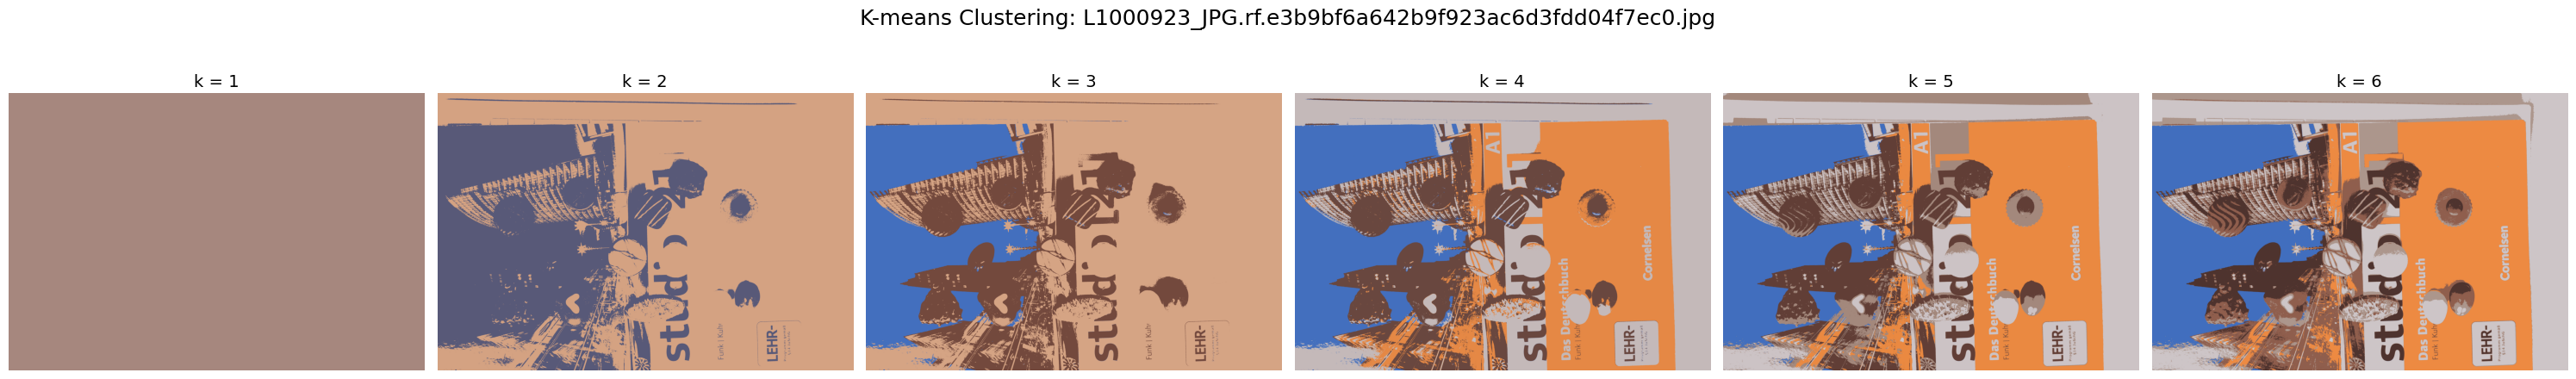

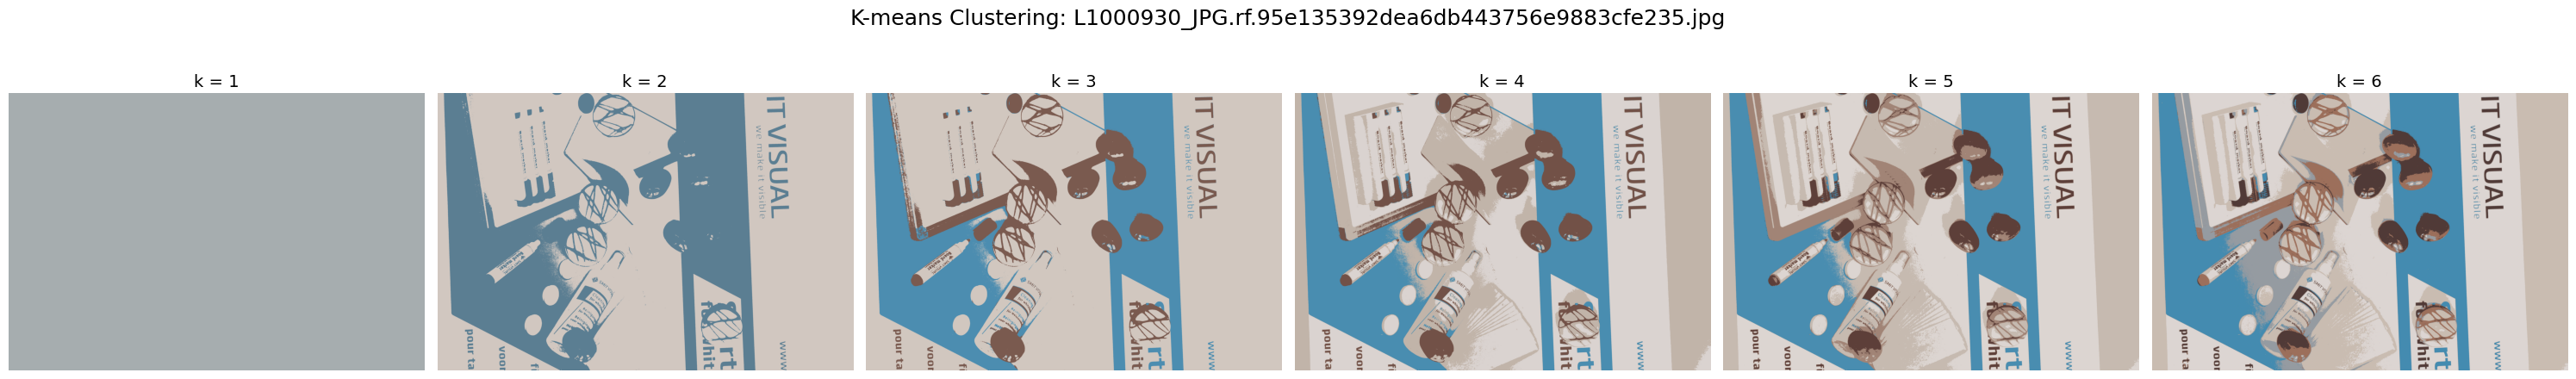

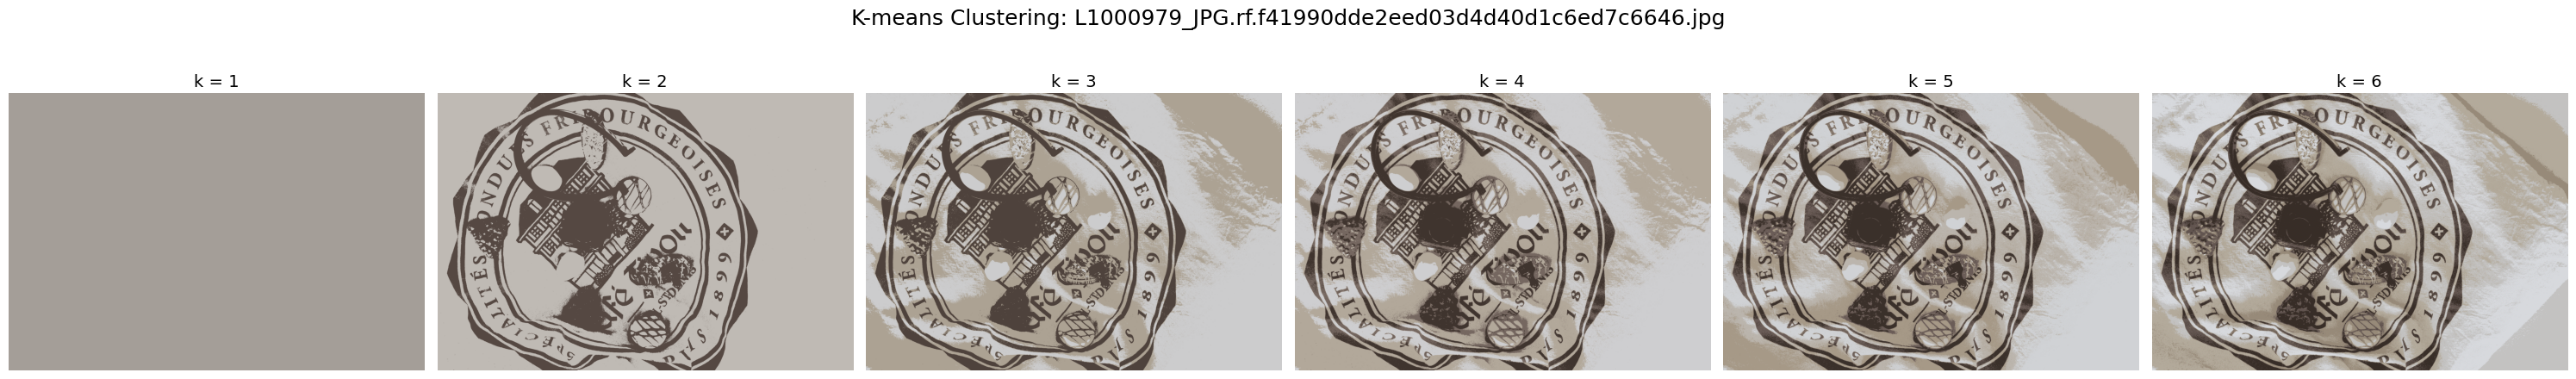

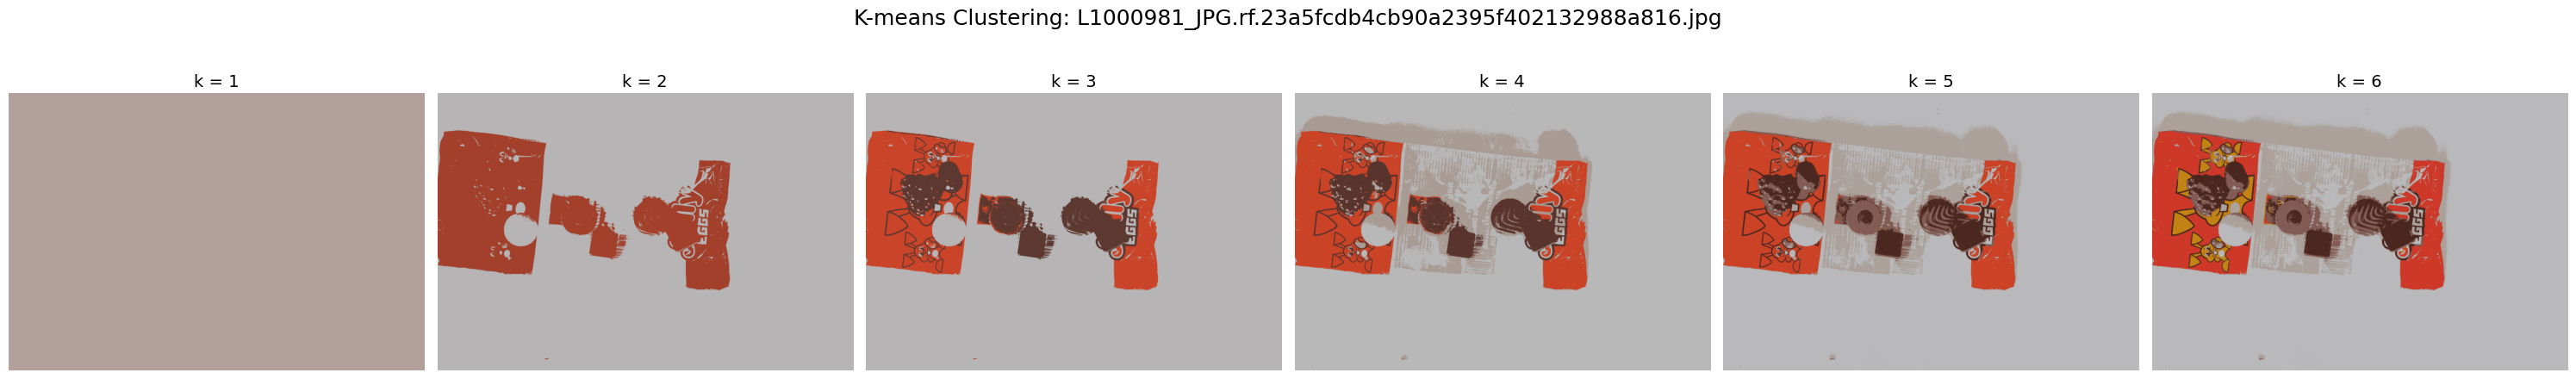

In [4]:
from visualizations import kmeans_comparisons
kmeans_comparisons(kmeans_clustering, visualize_img, 6)



*Figure 2:* From the images above we concluded that the appropriate value of k varies depending on the characteristics of the image. That means, on images with a uniform whitish background, k = 3 is sufficient to separate chocolates from the background. For images with more complex or colorful backgrounds, increasing to k = 4 helps separate additional distracting elements. Using values higher than k = 4 tends to introduce unnecessary detail without improving the outcome.

### Masks
The function extract_class_mask converts the clustered images, resulting from the K-meaning clustering, into a binary mask to identify object regions. These mask are passed to the clean_mask function where morphological cleaning is applied. This removes noise, fills holes, and enhances object boundaries. The cleaned mask are important to be able to create appropriate bounding boxes in the subsequential steps.

In [ ]:
def extract_class_masks(labels, num_classes=4):
    masks = []
    for i in range(num_classes):
        mask = np.uint8(labels == i) * 255
        masks.append(mask)
    return masks

def clean_mask(mask, open, close, element):
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open, open))
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (close, close))

    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close)
    
    # Optional: strengthen structure further
    dilated = cv2.dilate(closed, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (element, element)), iterations=1)
    return dilated

In [ ]:
from visualizations import visualize_all_mask_cleaning
vis_img = os.path.abspath(os.path.join('images', 'report_visualization\L1000780_JPG.rf.1cfecfde1b5d04b64aa295e9c884f82b.jpg'))

clustered_img, labels = kmeans_clustering(cv2.imread(vis_img))
mask_img = extract_class_masks(labels, num_classes=4)
visualize_all_mask_cleaning(mask_img, clean_mask, 11, 15, 7)
visualize_all_mask_cleaning(mask_img, clean_mask, 35, 55, 21)

*Figure 3:* In the image above, the transformation from raw segmentation to clean object masks is showed. To clearly illustrate the effects of morphological operations like opening and closing, we used relatively large structuring elements. However, this resulted in an aggressive transformation that was not suitable for precise further processing. In the final implementation, we used more moderate structuring elements. This helped us to get more appropriate masks for contour extraction and classification.

### Get contours
The `get_contours_from_mask` function extracts objects contours from a cleaned binary mask using `findContours` from the OpenCV library, which detects the outer boundaries of white regions. To eliminate noise and irrelevant regions, the function applies constraints on contour area and bounding box size, ensuring that only objects within a specified size range are retained. The size range is based on the mean size of all chocolate bounding boxes annotated by hand. This helped us to avoid having bounding boxes that are way to small or too big.

In [28]:
def get_contours_from_mask(mask, min_area=1500, size_range=(350, 800)): #Change here 450 to 700
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if (min_area < cv2.contourArea(c) and
            size_range[0] <= w <= size_range[1] and
            size_range[0] <= h <= size_range[1]):
            filtered.append(c)
    return filtered

### Create histograms
As a next step we built color-based feature representations of objects. `extract_histogram` extracts a color histogram from a detected object region, capturing the color distribution as a feature vector. `load_reference_histograms_from_annotations` uses the training images and extracts for each chocolate type a mean histogram over all the bounding boxes respective to this type, building a reference data for later comparison. 

In [ ]:
def extract_histogram(img, contour):
    x, y, w, h = cv2.boundingRect(contour)
    roi = img[y:y+h, x:x+w]
    hist = cv2.calcHist([roi], [0, 1, 2], None, [8,8,8], [0,256,0,256,0,256])
    cv2.normalize(hist, hist)
    return hist.flatten()


def load_reference_histograms_from_annotations(csv_path, train_folder):
    df = pd.read_csv(csv_path)

    # To store histograms per class
    histograms_by_class = defaultdict(list)

    for _, row in df.iterrows():
        filename = row['filename']
        img_path = os.path.join(train_folder, filename)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Failed to load image {img_path}")
            continue

        x_min, y_min, x_max, y_max = int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])
        cls = row['class']

        # Crop region and extract histogram
        roi = img[y_min:y_max, x_min:x_max]
        if roi.size == 0:
            print(f"Warning: Empty ROI for {filename} {cls}")
            continue

        hist = cv2.calcHist([roi], [0, 1, 2], None, [8,8,8], [0,256,0,256,0,256])
        cv2.normalize(hist, hist)
        histograms_by_class[cls].append(hist.flatten())

    # Compute mean histogram per class
    mean_histograms = {}
    for cls, hist_list in histograms_by_class.items():
        mean_hist = np.mean(hist_list, axis=0)
        mean_histograms[cls] = mean_hist

    print(f"Computed histograms for {len(mean_histograms)} classes.")
    return mean_histograms


We computed the reference histograms for the different chocolate types as well as for the object types and strong background contours present in the whole training set. Those are the histograms to which we will compare histograms of detected objects in the test set later. 

In [ ]:
total_train_img = os.path.abspath(os.path.join('images', 'train_total'))
ref_histograms = load_reference_histograms_from_annotations(annot_choc, total_train_img)
obj_histograms = load_reference_histograms_from_annotations(annot_obj, total_train_img)


Computed histograms for 13 classes.
Computed histograms for 34 classes.


The `match_histogram`function compares the histogram from a detected object to two sets of reference histograms. 
- Comparing it to the averaged chocolate histograms
- Comparing it to non-target or background object histograms

It finds the best matching histogram, and only returns a corresponding label if it is a chocolate type.

In [31]:
def match_histogram(hist, ref_chocolates, ref_objects):
    best_label = None
    best_score = -1

    # Compare to chocolate reference histograms
    for label, ref_hist in ref_chocolates.items():
        score = cv2.compareHist(hist, ref_hist, cv2.HISTCMP_CORREL)
        if score > best_score:
            best_score = score
            best_label = label
            best_from = 'chocolate'

    # Compare to object reference histograms
    for label, ref_hist in ref_objects.items():
        score = cv2.compareHist(hist, ref_hist, cv2.HISTCMP_CORREL)
        if score > best_score:
            best_score = score
            best_label = label
            best_from = 'object'

    # Only return label if it matched a chocolate, not an object
    return best_label if best_from == 'chocolate' else None


The `compute_overlap_ratio`function calculates the overlap ratio between two bounding boxes. This overlap ratio we use in the `filter_overlapping_boxes`function to remove redundant or overlapping detections. The function uses confidence scores to resolve overlaps; if the overlap ration exceeds the defined threshold, it keeps only the box with the higher score and discards the one wit the lower score.

In [32]:
def compute_overlap_ratio(box1, box2):
    # (x, y, w, h)
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # Convert to x_min, y_min, x_max, y_max
    xa1, ya1, xa2, ya2 = x1, y1, x1 + w1, y1 + h1
    xb1, yb1, xb2, yb2 = x2, y2, x2 + w2, y2 + h2

    # Compute intersection
    xi1 = max(xa1, xb1)
    yi1 = max(ya1, yb1)
    xi2 = min(xa2, xb2)
    yi2 = min(ya2, yb2)

    iw = max(0, xi2 - xi1)
    ih = max(0, yi2 - yi1)
    inter_area = iw * ih

    area1 = w1 * h1
    area2 = w2 * h2
    overlap_ratio = inter_area / min(area1, area2) if min(area1, area2) > 0 else 0


    return overlap_ratio

def filter_overlapping_boxes(detections, overlap_thresh=0.1):
    keep = [True] * len(detections)

    for i, j in itertools.combinations(range(len(detections)), 2):
        if not keep[i] or not keep[j]:
            continue

        boxA = detections[i]['bbox']
        boxB = detections[j]['bbox']
        overlap = compute_overlap_ratio(boxA, boxB)

        if overlap >= overlap_thresh:
            # Compare scores
            if detections[i]['score'] >= detections[j]['score']:
                keep[j] = False
            else:
                keep[i] = False

    return [det for k, det in enumerate(detections) if keep[k]]




`process_image` is the main function that we use to assign the labels to the chocolates. It uses the previously defined functions. First we convert the image to a k-mean image. Then we extract a masks for each of the k classes. These are then used to extract the contours with the right size. For each contour detected, a bounding box is created. From this bounding box we extract a color histogram, which are then compared to the reference histograms extracted from the hand-annotated images for chocolates and objects. For each contour the box and the best label are stored in a list `all_contours`and `all_labels`. These lists are then cleaned by removing first all the boxes that are labeled as a object. Then we remove the boxes that are overlapping by at least 10%. We observed that often there are multiple boxes, that are almost at the same position. They emerge mostly from the chocolate and its shadow, which are represented in two different k-mean classes and thus detected as two different contours. To decide which of the two boxes to keep, we compute for each chocolate detection a score of how accurately it matches the corresponding reference histogram. `filter_overlapping_boxes` discards the box with the lower score.

In [33]:
from visualizations import display_results

def process_image(img_path, reference_histograms, reference_histograms_objects, k=4, visualize=False, overlap=True):
    img = cv2.imread(img_path)
    clustered_img, labels = kmeans_clustering(img, k)
    class_masks = extract_class_masks(labels, k)

    all_contours = []
    all_labels = []
    choc_contours = []
    choc_labels = []
    no_over_choc_contours = []
    no_over_choc_labels = []

    chocolate_detections = []

    for mask in class_masks:
        cleaned = clean_mask(mask)
        contours = get_contours_from_mask(cleaned)
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            roi = img[y:y+h, x:x+w]
            if roi.size == 0:
                continue

            hist = extract_histogram(img, cnt)
            best_label = match_histogram(hist, reference_histograms, reference_histograms_objects)
            
            all_contours.append(cnt)
            all_labels.append(best_label)

            if best_label:
                choc_contours.append(cnt)
                choc_labels.append(best_label)

                score = cv2.compareHist(hist, reference_histograms[best_label], cv2.HISTCMP_CORREL)
                chocolate_detections.append({
                    'contour': cnt,
                    'label': best_label,
                    'score': score,
                    'bbox': (x, y, w, h)
                })

    # Overlap filtering on chocolate detections
    if overlap:
        filtered = filter_overlapping_boxes(chocolate_detections, overlap_thresh=0.1)
    else:
        filtered = chocolate_detections

    for d in filtered:
        no_over_choc_contours.append(d['contour'])
        no_over_choc_labels.append(d['label'])

    # Display
    if visualize:
        display_results(img, clustered_img, all_contours, all_labels, choc_contours, choc_labels, no_over_choc_contours, no_over_choc_labels)
    
    return no_over_choc_contours, no_over_choc_labels



To better visualize the functioning of the main pipeline `process_image` the results can be displayed optionally. We applied the pipeline to the visualisation images, which plots the different steps. The plotting function `display_results` shows in the first two images the generated k-mean image (here with k=4) and the original image, each with all the detected boxes. In the next three images, the original image alongside different stages of detection process: first with bounding boxes for all regions classified as a chocolate type, then with each box lebeld by its predicted class, and finally after applying the overlap filtering step.

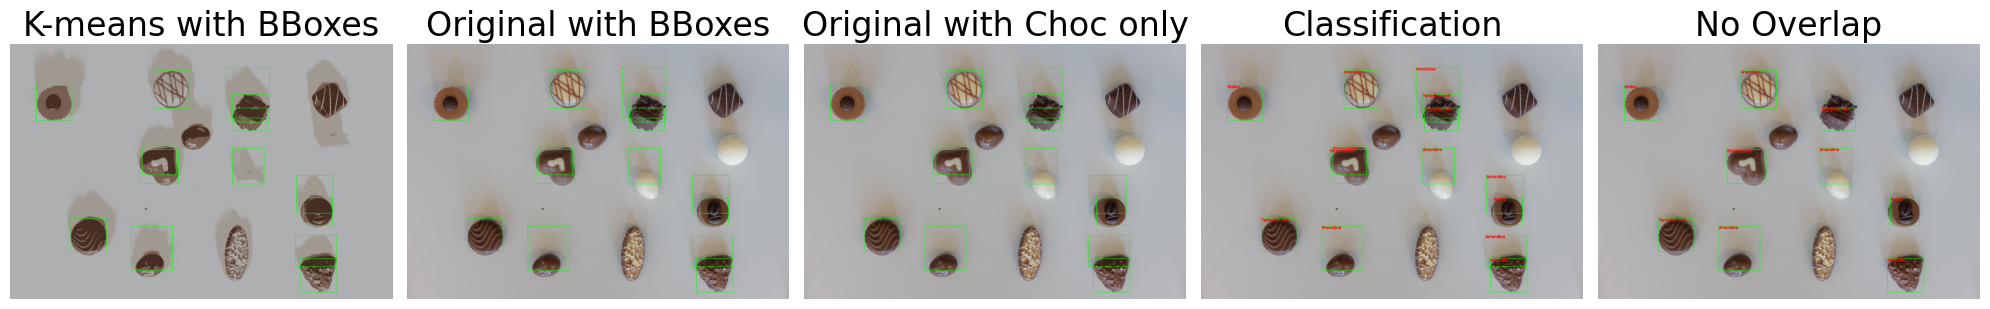

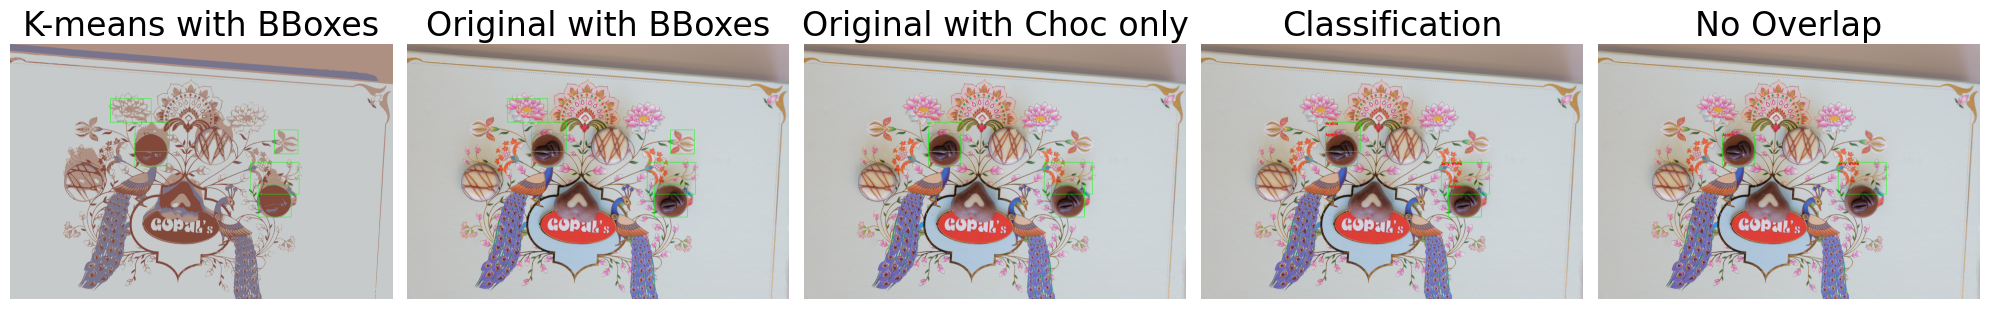

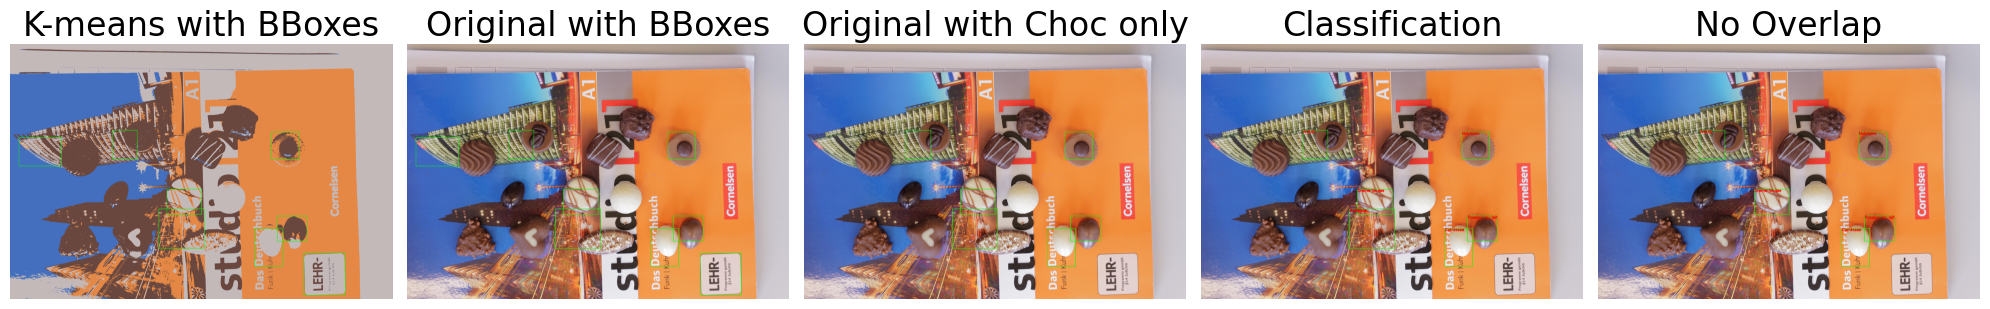

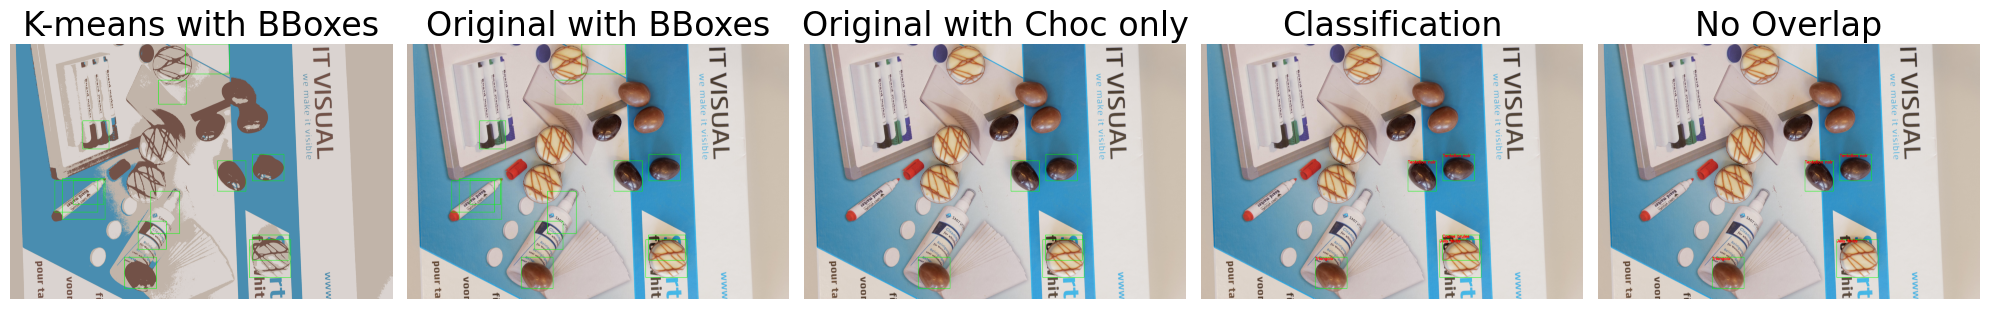

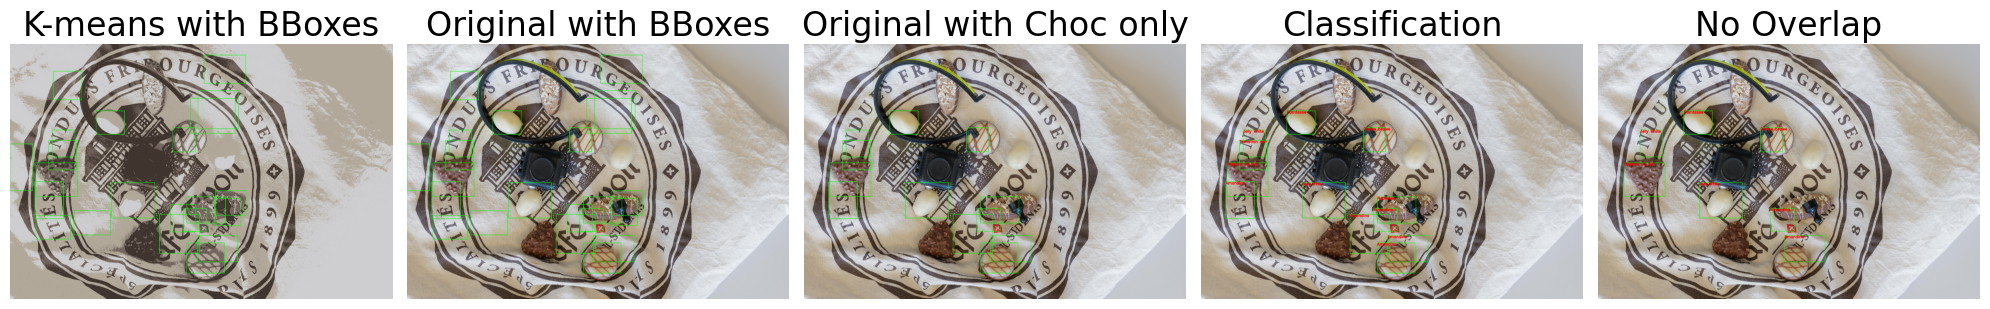

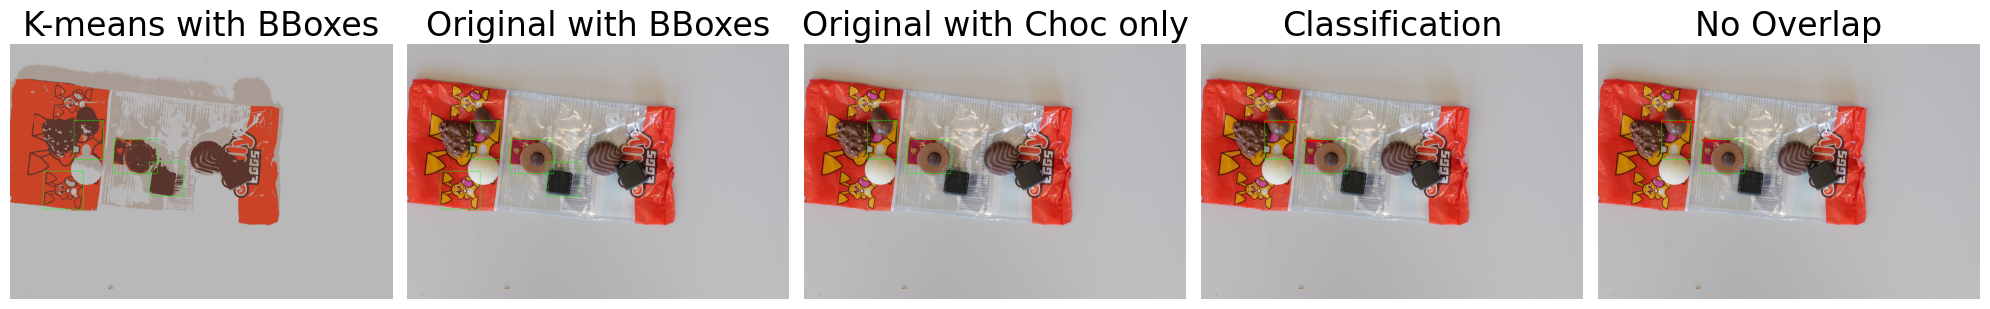

In [11]:
for img_path in glob(os.path.join(visualize_img, "*.jpg")):
    process_image(img_path, ref_histograms, obj_histograms, 4, visualize=True)

*Figure 4:* From the exapmle images we can see that the step which removes boxes from non-chocolate types is very important. There are many boxes that can be assigned to a object type. In these examples, no bounding boxes that clearly belong to a chocolate were removed, which confirms that this filtering step is working efficiently. Moreover the overlapping filter is very important especially on very noisy backgrounds and on backgrounds on which the shadows are very pronounced (especially plain white background). Despite of the good working of both filters, the overall results are not very satisfying. Many chocolate contours are still missed, and those detected are often misclassified. This is due to the contour detection and the histogram comparison, which are not very robust. The contour detection is much affected by the number of k classes, which is constant here. Also the contours could probably be improved by adapting the morphology of the different classes, which might enhance clear contours. The weak point for the histogram comparison is the fact that the histograms are made on the whole bounding boxes. These include especially the corners, on which the background is detected. We tested to take the histograms from the contours only. However this didn't really result in better histograms, as sometimes different parts of a chocolate are not counted as part of the contour. With that many important features were lost, resulting in bad histograms too.  

## Adaptive k for clustering
As we previously mentioned not every image has the same most efficient k. We observed that especially on plain white backgrounds a lot of shadows are detected. This makes sense as a white background, compared to a colorful background with a lot of variations doesn't have much information that could be splitted up by k-mean clustering. Therefore the classes are more distributed on the chocolates and on their shadows, leading to less accurate contour detection. In figure 2, one can see that for a white background k=2 already detects the dark shapes quite precisely. k=3 augments it, that also structures from white chocolates can be detected. k=4 brings too many details already. Therefore we would like to adapt the k to k=3 for all plain white images, and keep it at k=4 for all the oters. 
To detect uniform white and non uniform backgrounds to values are applied. First we use a variance treshold (0-100). This computes how much variance exists on the whole image by using a Laplacian. Images with a threshold lower than 14.0 are further considered. This value is determined by hand observing the tresholds of all train images. To all the images selected a second treshold was applied. This computes the white level by transforming the images to greyscale images, assigning to each pixel a value of 0 to 1 with 0 = black and 1 = white. Values above 0.6 are considered as white, as on a photo the white background is not completely white. The white_fraction is the fraction of pixels of the whole image that are considered as white. We again assigned manually a treshold of 0.8 to identify white surfaces. 
One of these parameters alon is not sufficient to detect the background accurately. The variance would also classify backgrounds with large colorful surfaces as white and the white fraction would consider backgrounds with thin patterns on white as plain white too. In the process of determing the optimal method and parameters other methods were tested such as clorfullness, checking different hues. These methods were however less promising. 

In [ ]:
def choose_k_by_variation_and_whiteness(image, var_thresh=14.0, white_thresh=0.8):
    # --- Variation (Laplacian) ---
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    var_laplacian = cv2.Laplacian(gray, cv2.CV_64F).var()

    # --- Whiteness ---
    small = cv2.resize(image, (100, 100))
    small_gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
    norm_gray = small_gray / 255.0
    white_fraction = (norm_gray > 0.6).mean()

    # --- Decision ---
    if var_laplacian < var_thresh and white_fraction > white_thresh:
        chosen_k = 3
    else:
        chosen_k = 4

    return chosen_k, (var_laplacian, white_fraction)


In [ ]:
from visualizations import display_kmeans_by_variation_and_whiteness
display_kmeans_by_variation_and_whiteness(visualize_img, kmeans_clustering, choose_k_by_variation_and_whiteness)

On this figure one can see that for each image the right k was chosen and that at least by eye the choice indeed makes sense. On the image with the white background a k=3 is enough to see the contours, however on the images with another background the additional class brings important features. The last image is for both parameters close to the decision boundary. One can see that there k=3 would probably be sufficient too. On other images tested with the same background it was advantageous to choose k=4 however. This shows that the boundaries are selected approximately right.

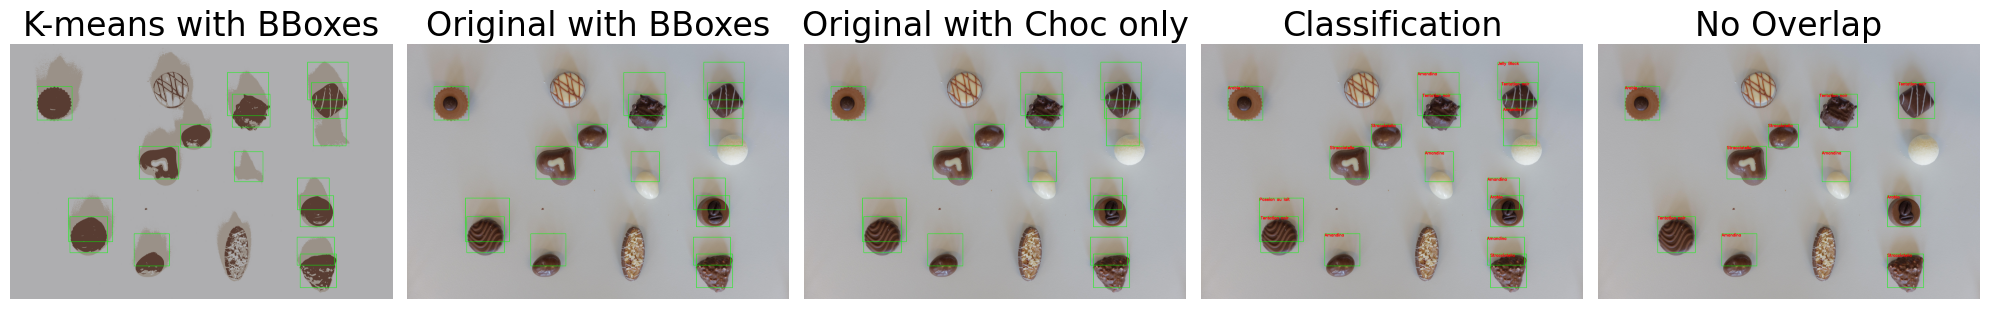

In [ ]:
visualize_img_0_path = os.path.abspath(os.path.join('images', 'report_visualization', 'L1000780_JPG.rf.1cfecfde1b5d04b64aa295e9c884f82b.jpg'))
visualize_img_0 = cv2.imread(visualize_img_0_path)
adaptive_k, _ = choose_k_by_variation_and_whiteness(visualize_img_0)
cont, lab = process_image(visualize_img_0_path, ref_histograms, obj_histograms, k=adaptive_k, visualize=True)

When visualizing agian the main pipeline for an adapted k for the first image, one sees that overall one chocolate more can be detected than with a standard k=4. However the Creme brulee could not be detected anymore. Showing that neither of both k is perfect.

In [12]:
EXPECTED_LABELS = [
    "Jelly White", "Jelly Milk", "Jelly Black", "Amandina", "Creme brulee",
    "Triangolo", "Tentation noir", "Comtesse", "Noblesse", "Noir authentique",
    "Passion au lait", "Arabia", "Stracciatella"
]

`process_images_for_counts` uses `process_images` to count for each image how many chocolates of each type are present. This is the required output in the submission file. The following code stores these values in a csv-outputfile. 

In [34]:
def process_image_for_counts(img_path, reference_histograms, reference_histograms_objects, k=4):
    _, choc_labels = process_image(img_path, reference_histograms, reference_histograms_objects, k, overlap=True)

    counts = {label: 0 for label in EXPECTED_LABELS}
    for label in choc_labels:
        if label in counts:
            counts[label] += 1

    return counts


In [36]:
def generate_csv(test_folder, reference_histograms, reference_histograms_objects, output_csv, adaptive_k=False):
    LABEL_NAME_MAPPING = {
        "Creme brulee": "Crème brulée"
    }

    # Update header with display labels
    header_labels = [LABEL_NAME_MAPPING.get(label, label) for label in EXPECTED_LABELS]

    with open(output_csv, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['id'] + header_labels)

        for img_path in glob(os.path.join(test_folder, '*.jpg')):
            filename = os.path.basename(img_path)

            # Extract image ID
            if filename.lower().startswith('l') and filename.lower().endswith('.jpg'):
                img_id = filename[1:filename.lower().rindex('.')]
            else:
                print(f"Unexpected filename format: {filename}")
                continue
            if adaptive_k:
                k, _ = choose_k_by_variation_and_whiteness(cv2.imread(img_path))
            else:
                k = 4
            counts = process_image_for_counts(img_path, reference_histograms, reference_histograms_objects,k)

            if counts is not None:
                row = [img_id] + [counts[label] for label in EXPECTED_LABELS]
                writer.writerow(row)
                print(f"Processed: {img_id}")
    print(f"CSV file generated: {output_csv}")


In [ ]:
test_images = os.path.abspath(os.path.join('images', 'test'))
output_csv = os.path.abspath(os.path.join('chocolate_counts.csv'))
generate_csv(
    test_images,
    ref_histograms,
    obj_histograms,
    output_csv,
    adaptive_k = True
)


Processed: 1000757
Processed: 1000758
Processed: 1000759
Processed: 1000760
Processed: 1000761
Processed: 1000762
Processed: 1000764
Processed: 1000766
Processed: 1000767
Processed: 1000769
Processed: 1000770
Processed: 1000773
Processed: 1000774
Processed: 1000775
Processed: 1000776
Processed: 1000777
Processed: 1000778
Processed: 1000781
Processed: 1000782
Processed: 1000783
Processed: 1000784
Processed: 1000786
Processed: 1000789
Processed: 1000790
Processed: 1000794
Processed: 1000795
Processed: 1000796
Processed: 1000798
Processed: 1000800
Processed: 1000801
Processed: 1000806
Processed: 1000807
Processed: 1000809
Processed: 1000811
Processed: 1000813
Processed: 1000814
Processed: 1000816
Processed: 1000818
Processed: 1000819
Processed: 1000822
Processed: 1000823
Processed: 1000824
Processed: 1000825
Processed: 1000829
Processed: 1000830
Processed: 1000832
Processed: 1000833
Processed: 1000834
Processed: 1000835
Processed: 1000837
Processed: 1000839
Processed: 1000840
Processed: 1